<div align="center">

# ***Klasifikasi Limbah Padat***
# ***BDC Satria Data 2026***

</div>

Notebook pipeline lengkap: Eksplorasi Data, Preprocessing, Modelling, dan Submission.

### ***Setup***

Environment detection, dataset download, dan instalasi dependensi untuk local / Kaggle / Colab.


In [6]:
!git clone https://github.com/FaarisKhairrudin/waste-image-classification.git
%cd waste-image-classification

Cloning into 'waste-image-classification'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 46 (delta 12), reused 42 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 729.08 KiB | 2.40 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/waste-image-classification


In [7]:
# ============= ENVIRONMENT SETUP ==============
import os, sys, subprocess, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Detect platform
IN_COLAB = False
IN_KAGGLE = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    pass
if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    IN_KAGGLE = True

# Project root
if IN_COLAB:
    # from google.colab import drive
    # drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/waste-image-classification')
    print(f'Platform: Google Colab')
elif IN_KAGGLE:
    PROJECT_ROOT = Path('/kaggle/working')
    # Kaggle usually has data in /kaggle/input/
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists() and any(kaggle_input.iterdir()):
        print(f'Kaggle input detected at {kaggle_input}')
    print(f'Platform: Kaggle')
else:
    PROJECT_ROOT = Path().resolve()
    print(f'Platform: Local ({PROJECT_ROOT})')

os.chdir(str(PROJECT_ROOT))

# Create directories
for d in ['data/raw', 'data/processed', 'outputs/figures', 'outputs/models', 'outputs/submissions', 'outputs/checkpoints']:
    (PROJECT_ROOT / d).mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data exists: train={ (PROJECT_ROOT / "data" / "raw" / "train").exists() } | test={ (PROJECT_ROOT / "data" / "raw" / "test").exists() }')


Platform: Google Colab
Project root: /content/waste-image-classification
Data exists: train=False | test=False


In [8]:
# ============= DOWNLOAD DATASET ==============
GDRIVE_TRAIN_ZIP_ID = '162_n3m5p9I_XD3YXZdZetMcw4u7amFVU'  # train.zip
GDRIVE_TEST_ZIP_ID  = '1LcLhIWfrLNnGQepyJVuudJiNnOEL7G35'  # test.zip
GDRIVE_SUB_CSV_ID   = '1GiRvwB13vCmHXcPmkr9EoTBaDS9RjXQ7'  # submission.csv

import os, zipfile
RAW = PROJECT_ROOT / 'data' / 'raw'
TRAIN_EXISTS = (RAW / 'train').exists()
TEST_EXISTS = (RAW / 'test').exists()
SUB_EXISTS = (RAW / 'submission.csv').exists()

if not (TRAIN_EXISTS and TEST_EXISTS and SUB_EXISTS):
    !pip install gdown -q
    print('Downloading dataset...')

    # ----- Train -----
    if not TRAIN_EXISTS:
        train_zip_path = RAW / 'train.zip'
        if GDRIVE_TRAIN_ZIP_ID:
            !gdown {GDRIVE_TRAIN_ZIP_ID} -O {train_zip_path} --remaining-ok
        else:
            # Fallback: download folder via gdown (lebih lambat)
            print('  No train zip file ID; downloading folder (this may be slow)...')
            !gdown --folder 1mVsWMnr2nmRotVjndbej9ONQmM6y5-q9 -O {RAW / 'train_dl'} --remaining-ok
            zips = list((RAW / 'train_dl').glob('*.zip'))
            if zips:
                zips[0].rename(train_zip_path)
                import shutil; shutil.rmtree(RAW / 'train_dl')
            else:
                (RAW / 'train_dl').rename(RAW / 'train')
                TRAIN_EXISTS = True
        if not TRAIN_EXISTS and train_zip_path.exists():
            print('  Extracting train.zip...')
            with zipfile.ZipFile(train_zip_path) as zf:
                zf.extractall(RAW / 'train')
            train_zip_path.unlink()

    # ----- Test -----
    if not TEST_EXISTS:
        test_zip_path = RAW / 'test.zip'
        if GDRIVE_TEST_ZIP_ID:
            !gdown {GDRIVE_TEST_ZIP_ID} -O {test_zip_path} --remaining-ok
        else:
            print('  No test zip file ID; downloading folder (this may be slow)...')
            !gdown --folder 1s9X4xtl5XeR9Fpmtw7WVTHfKozkUylM4 -O {RAW / 'test_dl'} --remaining-ok
            zips = list((RAW / 'test_dl').glob('*.zip'))
            if zips:
                zips[0].rename(test_zip_path)
                import shutil; shutil.rmtree(RAW / 'test_dl')
            else:
                (RAW / 'test_dl').rename(RAW / 'test')
                TEST_EXISTS = True
        if not TEST_EXISTS and test_zip_path.exists():
            print('  Extracting test.zip...')
            with zipfile.ZipFile(test_zip_path) as zf:
                zf.extractall(RAW / 'test')
            test_zip_path.unlink()

    # ----- Submission CSV -----
    if not SUB_EXISTS and GDRIVE_SUB_CSV_ID:
        print('  Downloading submission.csv...')
        !gdown {GDRIVE_SUB_CSV_ID} -O {RAW / 'submission.csv'} --remaining-ok

    print('Download complete.')
else:
    print('Dataset already exists, skipping download.')

# Show final structure
for root, dirs, files in os.walk(str(RAW)):
    level = root.replace(str(RAW), '').count(os.sep)
    indent = ' ' * (level * 2)
    folder = os.path.basename(root) or 'raw'
    n_files = len(files)
    if n_files > 0:
        print(f'{indent}{folder}/ ({n_files} files)')
    else:
        subdirs = len(dirs)
        print(f'{indent}{folder}/ ({subdirs} subdirs)')


Downloading...
From (original): https://drive.google.com/uc?id=162_n3m5p9I_XD3YXZdZetMcw4u7amFVU
From (redirected): https://drive.google.com/uc?id=162_n3m5p9I_XD3YXZdZetMcw4u7amFVU&confirm=t&uuid=77fe4c49-215d-457d-b816-f730bb55d317
To: /content/waste-image-classification/data/raw/train.zip
100% 1.30G/1.30G [01:28<00:00, 14.7MB/s]
  Extracting train.zip...
Downloading...
From (original): https://drive.google.com/uc?id=1LcLhIWfrLNnGQepyJVuudJiNnOEL7G35
From (redirected): https://drive.google.com/uc?id=1LcLhIWfrLNnGQepyJVuudJiNnOEL7G35&confirm=t&uuid=a97b050d-7cf7-46ef-a4d5-a24035227792
To: /content/waste-image-classification/data/raw/test.zip
100% 106M/106M [00:02<00:00, 45.2MB/s]
  Extracting test.zip...
Downloading...
From: https://drive.google.com/uc?id=1GiRvwB13vCmHXcPmkr9EoTBaDS9RjXQ7
To: /content/waste-image-classification/data/raw/submission.csv
100% 7.65k/7.65k [00:00<00:00, 32.4MB/s]
Download complete.
raw/ (2 files)
  train/ (1 subdirs)
    train/ (3 subdirs)
      2_Organic/ 

In [9]:
# ============= INSTALL DEPENDENCIES ==============
import importlib, subprocess, sys

required = ['torch', 'torchvision', 'transformers', 'timm', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy', 'PIL', 'tqdm']
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f'Installing missing packages: {missing}')
    !pip install {' '.join(missing)} -q
    print('Done.')
else:
    print('All dependencies satisfied.')

# Version check
import torch, transformers
print(f'PyTorch: {torch.__version__} | Transformers: {transformers.__version__} | CUDA: {torch.cuda.is_available()}')


Installing missing packages: ['scikit-learn']
Done.
PyTorch: 2.11.0+cu128 | Transformers: 5.12.1 | CUDA: True


In [10]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

In [11]:
# Use PROJECT_ROOT from setup if defined, else resolve locally
try:
    PROJECT_ROOT
except NameError:
    _nb_dir = Path().resolve()
    PROJECT_ROOT = _nb_dir.parent if (_nb_dir.parent / '.git').exists() else _nb_dir

TRAIN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'train' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'raw' / 'test' / 'test'
CLASS_DIRS = ['0_Recyclable', '1_Electronic', '2_Organic']
CLASS_NAMES = ['Recyclable', 'Electronic', 'Organic']
NUM_CLASSES = len(CLASS_DIRS)

print(f'Train dir: {TRAIN_DIR}')
print(f'Test dir:  {TEST_DIR}')
print(f'Classes:   {dict(zip(CLASS_DIRS, CLASS_NAMES))}')


Train dir: /content/waste-image-classification/data/raw/train/train
Test dir:  /content/waste-image-classification/data/raw/test/test
Classes:   {'0_Recyclable': 'Recyclable', '1_Electronic': 'Electronic', '2_Organic': 'Organic'}


## ***Eksplorasi Data***
---

Analisis awal dataset untuk memahami karakteristik citra di setiap kelas.

### ***Distribusi Kelas***

In [ ]:
train_paths = {}
for cls in CLASS_DIRS:
    paths = sorted(p for p in (TRAIN_DIR / cls).iterdir() if p.suffix.lower() in ('.jpg', '.jpeg', '.png'))
    train_paths[cls] = paths

counts = {cls: len(paths) for cls, paths in train_paths.items()}
total = sum(counts.values())

for cls, n in counts.items():
    print(f'{cls:20s}: {n:>6,}  ({n/total*100:5.1f}%)')
print(f'{"Total":20s}: {total:>6,}')
print(f'\nImbalance ratio (max/min): {max(counts.values())/min(counts.values()):.2f}')

0_Recyclable        :  9,999  ( 37.7%)
1_Electronic        :  3,961  ( 14.9%)
2_Organic           : 12,567  ( 47.4%)
Total               : 26,527

Imbalance ratio (max/min): 3.17


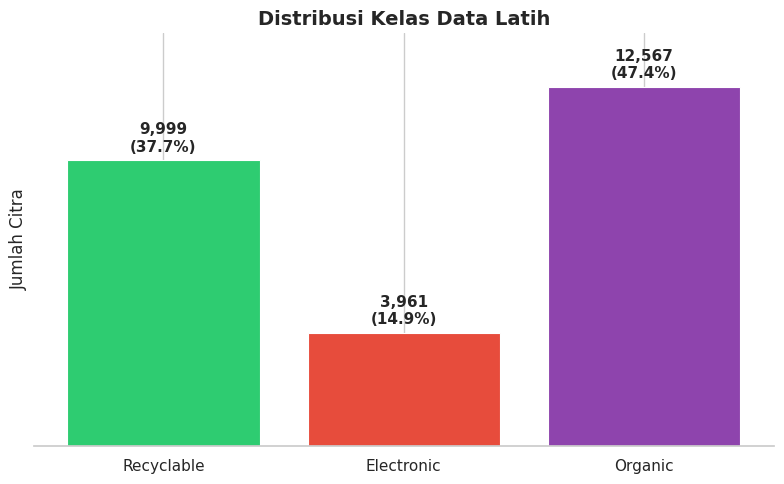

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#8e44ad']
bars = ax.bar(CLASS_NAMES, [counts[c] for c in CLASS_DIRS], color=colors, edgecolor='white', linewidth=0.8)

for bar, cnt, cls_name in zip(bars, counts.values(), CLASS_NAMES):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}\n({cnt/total*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribusi Kelas Data Latih', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Citra')
ax.set_ylim(0, max(counts.values()) * 1.15)
ax.set_yticks([])
sns.despine(left=True)
plt.tight_layout()
plt.show()

Dataset tidak seimbang. Kelas Organic hampir 3x lebih banyak dari Electronic. Perlu strategi handling imbalance pada tahap modelling (weighted loss, oversampling, atau Focal Loss).

### ***Sampel Gambar per Kelas***

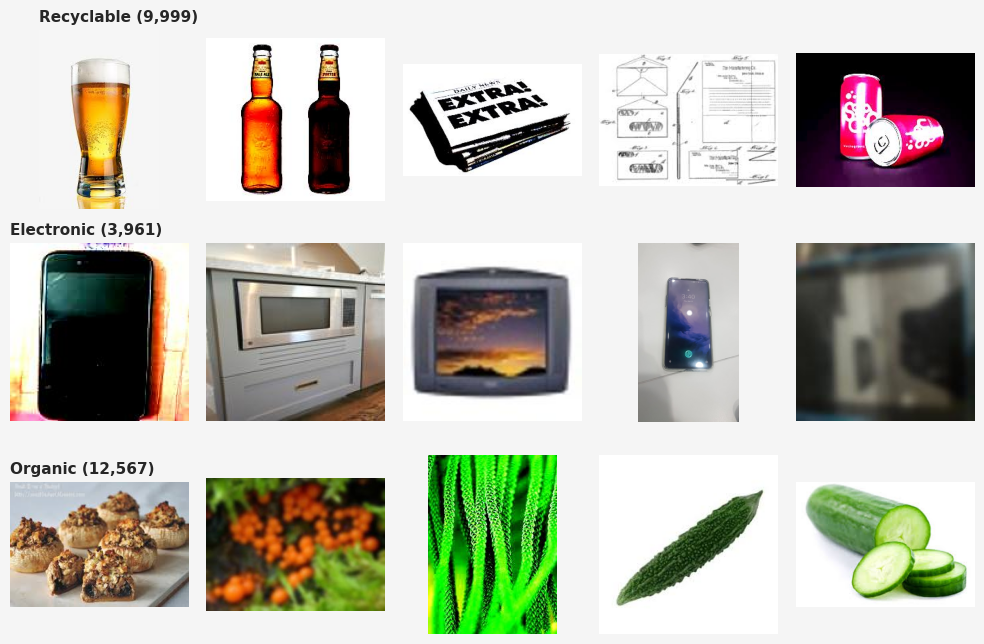

In [ ]:
def show_samples(paths_dict, n_cols=5):
    n_rows = len(paths_dict)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2.2 * n_rows))
    fig.patch.set_facecolor('#f5f5f5')
    for i, (cls, paths) in enumerate(paths_dict.items()):
        name = CLASS_NAMES[CLASS_DIRS.index(cls)]
        samples = random.sample(paths, min(n_cols, len(paths)))
        for j, img_path in enumerate(samples):
            img = Image.open(img_path).convert('RGB')
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f'{name} ({len(paths):,})', fontsize=11, fontweight='bold', loc='left')
    plt.subplots_adjust(wspace=0.05, hspace=0.1)
    plt.tight_layout()
    plt.show()

show_samples(train_paths)

Sampel memperlihatkan variasi tinggi dalam angle, pencahayaan, latar belakang, dan skala objek antar kelas. Data augmentation akan sangat diperlukan.

### ***Dimensi Gambar***

In [ ]:
def collect_size_stats(paths_dict, max_samples=3000):
    records = []
    for cls, paths in paths_dict.items():
        sample = random.sample(paths, min(max_samples, len(paths)))
        for p in tqdm(sample, desc=f'Scanning {cls}'):
            try:
                with Image.open(p) as img:
                    w, h = img.size
                    records.append({'class': CLASS_NAMES[CLASS_DIRS.index(cls)], 'width': w, 'height': h, 'aspect': w / h, 'file': p})
            except Exception:
                pass
    return pd.DataFrame(records)

size_df = collect_size_stats(train_paths)

Scanning 2_Organic: 100%|██████████| 3000/3000 [00:00<00:00, 7695.79it/s]


In [ ]:
summary = size_df.groupby('class').agg(
    width_min=('width', 'min'), width_med=('width', 'median'), width_max=('width', 'max'),
    height_min=('height', 'min'), height_med=('height', 'median'), height_max=('height', 'max'),
    n=('width', 'count')
).astype(int)
summary

,width_min,width_med,width_max,height_min,height_med,height_max,n
class,,,,,,,
Electronic,150,150,8000,113,150,6000,3000
Organic,75,263,600,69,190,318,3000
Recyclable,65,225,545,92,222,318,3000


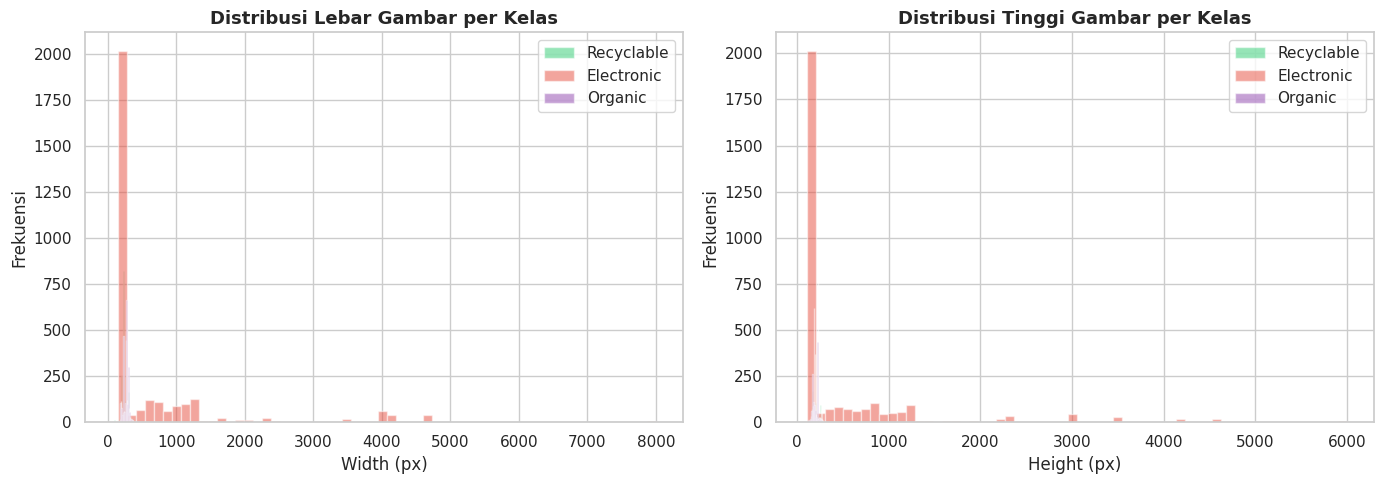

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width distribution
for i, cls in enumerate(CLASS_NAMES):
    subset = size_df[size_df['class'] == cls]['width']
    axes[0].hist(subset, bins=60, alpha=0.5, label=cls, color=colors[i])
axes[0].set_title('Distribusi Lebar Gambar per Kelas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Height distribution
for i, cls in enumerate(CLASS_NAMES):
    subset = size_df[size_df['class'] == cls]['height']
    axes[1].hist(subset, bins=60, alpha=0.5, label=cls, color=colors[i])
axes[1].set_title('Distribusi Tinggi Gambar per Kelas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()
plt.tight_layout()
plt.show()

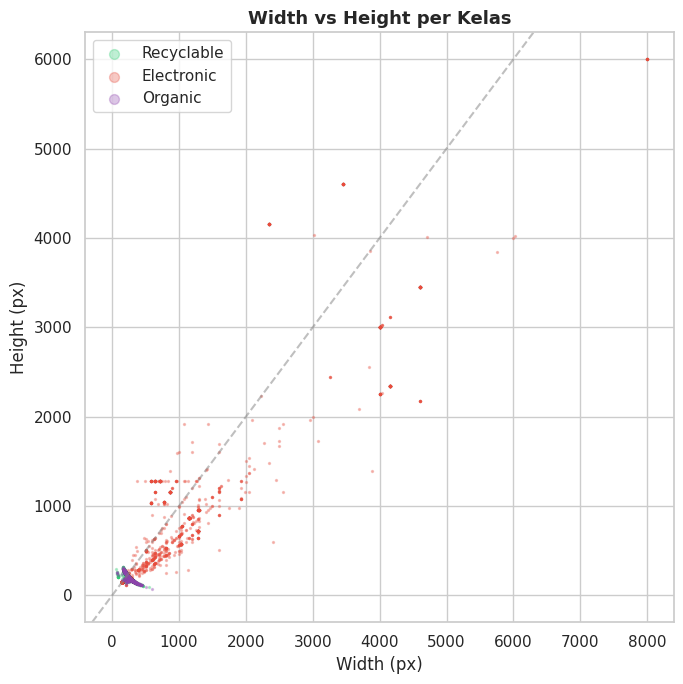

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
for i, cls in enumerate(CLASS_NAMES):
    subset = size_df[size_df['class'] == cls]
    ax.scatter(subset['width'], subset['height'], s=2, alpha=0.3, c=colors[i], label=cls, rasterized=True)
ax.set_title('Width vs Height per Kelas', fontsize=13, fontweight='bold')
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
ax.legend(markerscale=5)
ax.axline((0, 0), slope=1, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Gambar memiliki rentang dimensi yang sangat lebar (dari puluhan hingga ribuan piksel). Resize ke ukuran seragam diperlukan sebelum modelling. Scatter plot menunjukkan tidak ada outlier dimensi yang ekstrem secara konsisten di satu kelas.

### ***Channel Statistics***

In [ ]:
def compute_channel_stats(paths, max_samples=2000):
    sums, sum_sq, n = np.zeros(3), np.zeros(3), 0
    sample = random.sample(paths, min(max_samples, len(paths)))
    for p in tqdm(sample, desc='Computing channel stats'):
        try:
            img = np.array(Image.open(p).convert('RGB'), dtype=np.float64) / 255.0
            sums += img.mean(axis=(0, 1))
            sum_sq += (img ** 2).mean(axis=(0, 1))
            n += 1
        except Exception:
            pass
    mean = sums / n
    std = np.sqrt(sum_sq / n - mean ** 2)
    return mean, std

all_train_paths = [p for paths in train_paths.values() for p in paths]
global_mean, global_std = compute_channel_stats(all_train_paths)

print(f'Per-channel Mean (R, G, B): {global_mean}')
print(f'Per-channel Std  (R, G, B): {global_std}')
print(f'\nImageNet comparison:')
print(f'ImageNet Mean: [0.485, 0.456, 0.406]')
print(f'ImageNet Std:  [0.229, 0.224, 0.225]')

Computing channel stats: 100%|██████████| 2000/2000 [00:39<00:00, 50.70it/s]

Per-channel Mean (R, G, B): [0.66181743 0.62039057 0.55375781]
Per-channel Std  (R, G, B): [0.32079995 0.32670213 0.35856592]

ImageNet comparison:
ImageNet Mean: [0.485, 0.456, 0.406]
ImageNet Std:  [0.229, 0.224, 0.225]


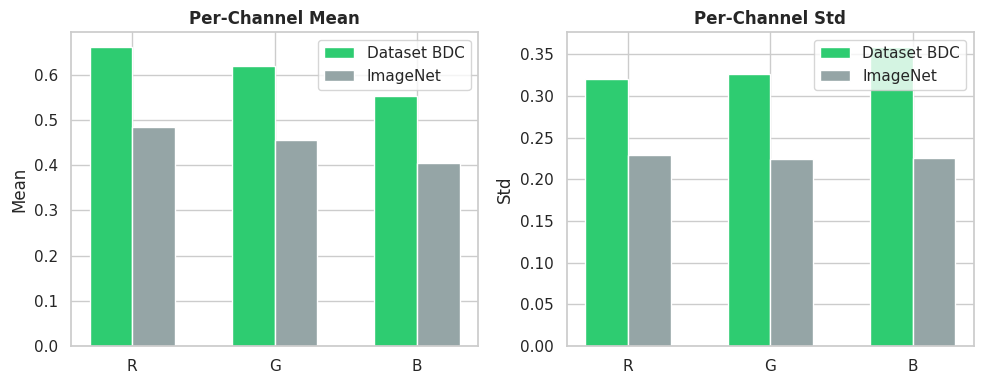

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

channels = ['R', 'G', 'B']
x = np.arange(3)
w = 0.3

axes[0].bar(x - w/2, global_mean, w, label='Dataset BDC', color=colors[0])
axes[0].bar(x + w/2, [0.485, 0.456, 0.406], w, label='ImageNet', color='#95a5a6')
axes[0].set_title('Per-Channel Mean', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(channels)
axes[0].legend()
axes[0].set_ylabel('Mean')

axes[1].bar(x - w/2, global_std, w, label='Dataset BDC', color=colors[0])
axes[1].bar(x + w/2, [0.229, 0.224, 0.225], w, label='ImageNet', color='#95a5a6')
axes[1].set_title('Per-Channel Std', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(channels)
axes[1].legend()
axes[1].set_ylabel('Std')
plt.tight_layout()
plt.show()

Channel statistics menunjukkan perbedaan dengan ImageNet, terutama pada channel R yang lebih tinggi. Gunakan normalisasi dari dataset ini sendiri pada modelling untuk hasil optimal, atau tetap gunakan ImageNet stats jika menggunakan backbone pre-trained secara langsung.

### ***Kualitas Gambar***

In [ ]:
def check_corrupted(train_paths):
    corrupted = []
    all_paths = [p for paths in train_paths.values() for p in paths]
    for p in tqdm(all_paths, desc='Checking integrity'):
        try:
            with Image.open(p) as img:
                img.verify()
        except Exception:
            corrupted.append(str(p))
    return corrupted

corrupted_files = check_corrupted(train_paths)
print(f'Corrupted files found: {len(corrupted_files)}')
if corrupted_files:
    for f in corrupted_files[:10]:
        print(f'  {f}')

Checking integrity: 100%|██████████| 26527/26527 [00:01<00:00, 15273.30it/s]

Corrupted files found: 0


In [ ]:
def detect_blurry(paths_dict, threshold=100, n_samples=60):
    results = []
    for cls, paths in paths_dict.items():
        sample = random.sample(paths, min(n_samples, len(paths)))
        for p in tqdm(sample, desc=f'Blur check {cls}'):
            try:
                img = Image.open(p).convert('L')
                arr = np.array(img, dtype=np.float64)
                gy, gx = np.gradient(arr)
                gmag = np.sqrt(gx**2 + gy**2)
                laplace_var = gmag.var()
                results.append({'class': CLASS_NAMES[CLASS_DIRS.index(cls)], 'laplace_var': laplace_var, 'file': p})
            except Exception:
                pass
    return pd.DataFrame(results)

blur_df = detect_blurry(train_paths)
blurry_threshold = blur_df['laplace_var'].quantile(0.02)
print(f'Laplacian variance 2nd percentile (blurry threshold): {blurry_threshold:.1f}')

Blur check 2_Organic: 100%|██████████| 60/60 [00:00<00:00, 822.62it/s]

Laplacian variance 2nd percentile (blurry threshold): 7.2


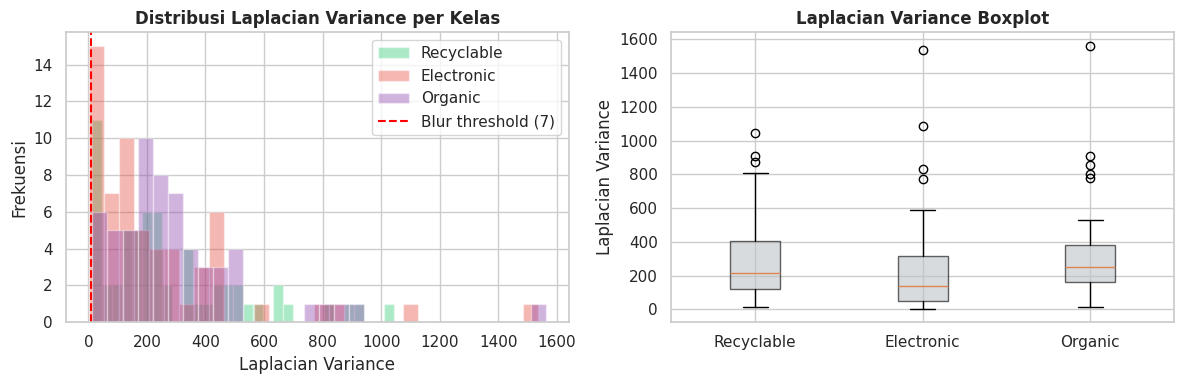

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-class blur distribution
for i, cls in enumerate(CLASS_NAMES):
    subset = blur_df[blur_df['class'] == cls]['laplace_var']
    axes[0].hist(subset, bins=30, alpha=0.4, label=cls, color=colors[i])
axes[0].axvline(blurry_threshold, color='red', linestyle='--', label=f'Blur threshold ({blurry_threshold:.0f})')
axes[0].set_title('Distribusi Laplacian Variance per Kelas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Laplacian Variance')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot
axes[1].boxplot([blur_df[blur_df['class'] == c]['laplace_var'] for c in CLASS_NAMES], labels=CLASS_NAMES, patch_artist=True,
                boxprops=dict(facecolor='#bdc3c7', alpha=0.6))
axes[1].set_title('Laplacian Variance Boxplot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Laplacian Variance')
plt.tight_layout()
plt.show()

Tidak ditemukan file korup. Beberapa gambar berada di bawah threshold blur, namun jumlahnya sedikit dan tersebar di semua kelas. Tidak perlu filtering agresif pada tahap ini -- augmentasi dan transfer learning akan menangani variasi kualitas gambar.

## ***Modelling***
---

ConvNeXt V2 Base (ImageNet-22K pretrained) dengan HuggingFace Trainer + Focal Loss.


### ***Configuration***


In [ ]:
import os, sys, random, json, warnings, math, gc
from pathlib import Path
from copy import deepcopy
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from PIL import Image

from torchvision import transforms
from transformers import (
    AutoModelForImageClassification,
    Trainer,
    TrainingArguments,
    EvalPrediction,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'Device: {device} | GPU: {gpu_name} | VRAM: {mem:.1f} GB')
else:
    print(f'Device: {device} (CPU mode)')


Device: cuda | GPU: Tesla T4 | VRAM: 14.6 GB


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Use PROJECT_ROOT from setup (defined earlier)
TRAIN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'train' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'raw' / 'test' / 'test'
SUBMISSION_TEMPLATE = PROJECT_ROOT / 'data' / 'raw' / 'submission.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
(OUTPUT_DIR / 'models').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'checkpoints').mkdir(exist_ok=True)
(OUTPUT_DIR / 'submissions').mkdir(exist_ok=True)

CLASS_DIRS = ['0_Recyclable', '1_Electronic', '2_Organic']
CLASS_NAMES = ['Recyclable', 'Electronic', 'Organic']
NUM_CLASSES = 3


In [ ]:
# ===== GLOBAL CONFIG =====
CFG = {
    'backbone': 'prithivMLmods/Augmented-Waste-Classifier-SigLIP2',
    'image_size': 224,
    'num_classes': 3,

    'epochs': 12,
    'batch_size': 16,
    'num_workers': 0,
    'accumulation_steps': 1,
    'grad_clip_norm': 1.0,

    'head_lr': 1e-3,
    'backbone_lr': 1e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.05,

    'loss_type': 'ce', # Diubah dari 'focal' ke 'ce'
    'focal_gamma': 2.0,
    'dropout': 0.3,

    'val_split': 0.2,
    'early_stop_patience': 7,
    'seed': 42,
    'amp': torch.cuda.is_available(),
}
print(json.dumps(CFG, indent=2))

{
  "backbone": "facebook/convnextv2-base-22k-224",
  "image_size": 224,
  "num_classes": 3,
  "epochs": 10,
  "batch_size": 32,
  "num_workers": 2,
  "accumulation_steps": 1,
  "grad_clip_norm": 1.0,
  "head_lr": 0.001,
  "backbone_lr": 5e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.05,
  "loss_type": "ce",
  "focal_gamma": 2.0,
  "dropout": 0.3,
  "val_split": 0.2,
  "early_stop_patience": 7,
  "seed": 42,
  "amp": true
}


In [ ]:
torch.cuda.empty_cache()

### ***Dataset & Transforms***


In [ ]:
# ===== FOCAL LOSS (functional, for compute_loss) ======
def focal_loss(logits, targets, alpha=None, gamma=2.0):
    ce = F.cross_entropy(logits, targets, reduction='none', weight=alpha)
    pt = torch.exp(-ce)
    return ((1 - pt) ** gamma * ce).mean()

# ===== DATASET ======
class WasteDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ===== TRANSFORMS ======
S = CFG['image_size']
MEAN, STD = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]  # SigLIP2 normalization (CLIP-style)

train_tf = transforms.Compose([
    transforms.Resize(int(S * 1.14)),
    transforms.RandomResizedCrop(S, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
val_tf = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ===== LOAD PATHS ======
all_paths, all_labels = [], []
for cls_idx, cls_dir in enumerate(CLASS_DIRS):
    paths = sorted(p for p in (TRAIN_DIR / cls_dir).iterdir() if p.suffix.lower() in ('.jpg', '.jpeg', '.png'))
    all_paths.extend(paths)
    all_labels.extend([cls_idx] * len(paths))
all_paths = np.array(all_paths)
all_labels = np.array(all_labels)
print(f'Total images: {len(all_paths)}')


Total images: 26527


In [ ]:
set_seed(CFG['seed'])

# Stratified split
sss = StratifiedShuffleSplit(n_splits=1, test_size=CFG['val_split'], random_state=CFG['seed'])
train_idx, val_idx = next(sss.split(all_paths, all_labels))

train_paths, val_paths = all_paths[train_idx], all_paths[val_idx]
train_labels, val_labels = all_labels[train_idx], all_labels[val_idx]

def print_dist(name, labels):
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    print(f'{name:10s}: {len(labels):>5} | {dict(zip(CLASS_NAMES, counts.tolist()))}')
print_dist('Train', train_labels)
print_dist('Val', val_labels)

# Datasets
train_ds = WasteDataset(train_paths, train_labels, transform=train_tf)
val_ds = WasteDataset(val_paths, val_labels, transform=val_tf)
_test_paths = sorted(
    [p for p in TEST_DIR.iterdir() if p.suffix.lower() in ('.jpg', '.jpeg', '.png')],
    key=lambda p: int(p.stem)
)
test_ds = WasteDataset(_test_paths, [0]*1458, transform=val_tf)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Train     : 21221 | {'Recyclable': 7999, 'Electronic': 3169, 'Organic': 10053}
Val       :  5306 | {'Recyclable': 2000, 'Electronic': 792, 'Organic': 2514}
Train: 21221 | Val: 5306 | Test: 1458


### ***Model & Trainer Setup***


In [ ]:
set_seed(CFG['seed'])

# Model
model = AutoModelForImageClassification.from_pretrained(
    CFG['backbone'],
    num_labels=CFG['num_classes'],
    ignore_mismatched_sizes=True,
).to(device)

# Replace classifier head with dropout
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=CFG['dropout']),
    nn.Linear(in_features, CFG['num_classes']),
).to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params: {total/1e6:.1f}M total, {trainable/1e6:.1f}M trainable')

# ===== DATA COLLATOR ======
class Collator:
    def __call__(self, features):
        pixel_values = torch.stack([f[0] for f in features])
        labels = torch.tensor([f[1] for f in features])
        return {'pixel_values': pixel_values, 'labels': labels}

# ===== OPTIMIZER with per-layer LR ======
backbone_p, head_p = [], []
for name, p in model.named_parameters():
    if not p.requires_grad: continue
    (head_p if 'classifier' in name else backbone_p).append(p)

optimizer = AdamW([
    {'params': backbone_p, 'lr': CFG['backbone_lr'], 'weight_decay': CFG['weight_decay']},
    {'params': head_p, 'lr': CFG['head_lr'], 'weight_decay': CFG['weight_decay']},
])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-6)

print(f'Backbone LR: {CFG["backbone_lr"]} | Head LR: {CFG["head_lr"]}')
print(f'Backbone params: {sum(p.numel() for p in backbone_p)/1e6:.1f}M | Head: {sum(p.numel() for p in head_p)/1e3:.0f}K')


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/355M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

[transformers] ConvNextV2ForImageClassification LOAD REPORT from: facebook/convnextv2-base-22k-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1024]) vs model:torch.Size([3, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Params: 87.7M total, 87.7M trainable
Backbone LR: 5e-05 | Head LR: 0.001
Backbone params: 87.7M | Head: 3K


In [ ]:
# ===== TRAINER DENGAN OPSI CROSS ENTROPY ATAU FOCAL LOSS =====
class WasteTrainer(Trainer):

    def __init__(self, class_weights=None, gamma=2.0, loss_type='ce', *args, **kwargs):
        self.waste_alpha = class_weights
        self.waste_gamma = gamma
        self.loss_type = loss_type
        super().__init__(*args, **kwargs)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)

        if self.loss_type == 'focal':
            loss = focal_loss(outputs.logits, labels, alpha=self.waste_alpha, gamma=self.waste_gamma)
        else:
            # Menggunakan Cross Entropy standar (dengan bobot kelas jika ada)
            loss = F.cross_entropy(outputs.logits, labels, weight=self.waste_alpha)

        return (loss, outputs) if return_outputs else loss

# ===== COMPUTE METRICS =====
def compute_metrics(eval_pred: EvalPrediction):
    preds = eval_pred.predictions.argmax(-1)
    macro = f1_score(eval_pred.label_ids, preds, average='macro')
    per = f1_score(eval_pred.label_ids, preds, average=None)
    return {
        'macro_f1': macro,
        'f1_recyclable': per[0],
        'f1_electronic': per[1],
        'f1_organic': per[2],
    }

# ===== TRAINING ARGUMENTS =====
args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    num_train_epochs=CFG['epochs'],
    per_device_train_batch_size=CFG['batch_size'],
    per_device_eval_batch_size=CFG['batch_size'],
    gradient_accumulation_steps=CFG['accumulation_steps'],
    max_grad_norm=CFG['grad_clip_norm'],
    warmup_ratio=CFG['warmup_ratio'],
    lr_scheduler_type='cosine',
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1', # Pastikan metrik ini konsisten
    greater_is_better=True,
    fp16=CFG['amp'],
    dataloader_num_workers=CFG['num_workers'],
    remove_unused_columns=False,
    report_to='none',
    logging_steps=50,
    seed=CFG['seed'],
    disable_tqdm=False,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
# ===== CREATE TRAINER =====
# Pastikan variabel dari sel sebelumnya sudah ada
try:
    train_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
    class_weights = torch.tensor(len(train_labels) / (NUM_CLASSES * train_counts), dtype=torch.float32).to(device)
    print(f'Class weights: {class_weights.tolist()}')

    trainer = WasteTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=Collator(),
        compute_metrics=compute_metrics,
        optimizers=(optimizer, scheduler),
        class_weights=class_weights,
        gamma=CFG['focal_gamma'],
        loss_type=CFG['loss_type'] # Menggunakan 'ce' dari config
    )
    print(f"Trainer created successfully using: {CFG['loss_type']}")
except NameError as e:
    print(f"Error: {e}. Pastikan Anda sudah menjalankan sel 'SZd5ros1GPBf' dan 'TviVhvo7GPBf' untuk mendefinisikan dataset dan labels.")

Class weights: [0.8843188881874084, 2.232144832611084, 0.7036373615264893]
Trainer created successfully using: ce


In [ ]:
# ===== TRAIN ======
set_seed(CFG['seed'])
trainer.train()

# Save weights only (avoid config mismatch with custom classifier)
torch.save(trainer.model.state_dict(), str(OUTPUT_DIR / 'models' / 'best_weights.pt'))
print(f'Weights saved to {OUTPUT_DIR / "models" / "best_weights.pt"}')


Epoch,Training Loss,Validation Loss,Macro F1,F1 Recyclable,F1 Electronic,F1 Organic
1,0.110744,0.078953,0.975544,0.965721,0.984829,0.976080
2,0.041937,0.131892,0.966295,0.951877,0.983439,0.963569
3,0.014194,0.106047,0.976723,0.968127,0.984167,0.977875
4,0.008202,0.116069,0.980591,0.973230,0.988043,0.980501
5,0.013373,0.130216,0.978492,0.969502,0.987982,0.977991
6,0.004962,0.141172,0.980719,0.972527,0.990524,0.979104
7,0.021787,0.148396,0.978395,0.971113,0.984326,0.979746
8,0.016206,0.219355,0.970830,0.958516,0.984167,0.969807
9,0.007468,0.167129,0.974811,0.964794,0.986129,0.973511
10,0.039671,0.157477,0.977160,0.970956,0.981250,0.979275


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Weights saved to /content/waste-image-classification/outputs/models/best_weights.pt


### ***Evaluation***


In [ ]:
# ===== EVALUATE ======
metrics = trainer.evaluate()
print(f'\nVal Macro F1: {metrics["eval_macro_f1"]:.4f}')
print(f'Per-class Recyclable: {metrics["eval_f1_recyclable"]:.4f}')
print(f'Per-class Electronic: {metrics["eval_f1_electronic"]:.4f}')
print(f'Per-class Organic:    {metrics["eval_f1_organic"]:.4f}')

# Full predictions for confusion matrix
preds = trainer.predict(val_ds)
y_pred = preds.predictions.argmax(-1)
y_true = preds.label_ids

print(f'\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4)}')


Training Loss,Validation Loss,Epoch,Macro F1,F1 Recyclable,F1 Electronic,F1 Organic
0.009667,0.045060,10,0.979654,0.970420,0.990488,0.978053



Val Macro F1: 0.9797
Per-class Recyclable: 0.9704
Per-class Electronic: 0.9905
Per-class Organic:    0.9781



              precision    recall  f1-score   support

  Recyclable     0.9649    0.9760    0.9704      2000
  Electronic     0.9949    0.9861    0.9905       792
     Organic     0.9812    0.9749    0.9781      2514

    accuracy                         0.9770      5306
   macro avg     0.9803    0.9790    0.9797      5306
weighted avg     0.9771    0.9770    0.9770      5306



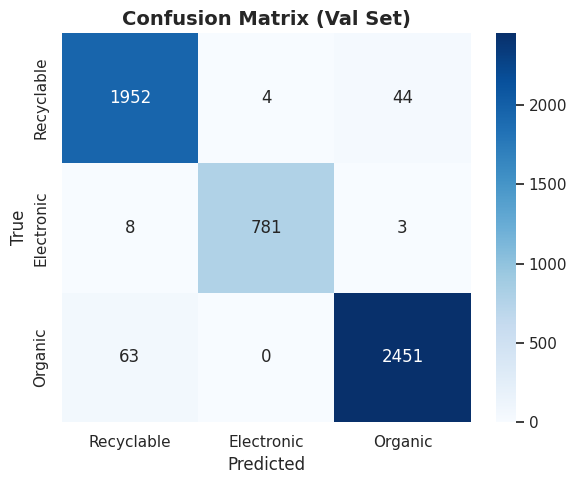

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix (Val Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()


### ***Test Inference & Submission***


In [ ]:
# Use best model from trainer (automatically restored by load_best_model_at_end)
model = trainer.model
model.eval()

# Inference
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size']*2, shuffle=False)
all_preds = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        logits = model(pixel_values=images).logits
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())

print(f'Prediction distribution: {np.bincount(all_preds, minlength=3)}')


Prediction distribution: [508 194 756]


In [ ]:
# Save submission
sub = pd.read_csv(SUBMISSION_TEMPLATE)
sub['predicted'] = all_preds
print(sub.head(10))

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = OUTPUT_DIR / 'submissions' / f'submission_NamaTim_{ts}.csv'
sub.to_csv(out, index=False)
print(f'Saved: {out}')

# Verify
v = pd.read_csv(out)
assert list(v.columns) == ['id', 'predicted'], f'Bad columns: {v.columns.tolist()}'
assert len(v) == 1458, f'Expected 1458 rows, got {len(v)}'
print(f'Verified: {len(v)} rows, columns={list(v.columns)}')


   id  predicted
0   1          2
1   2          2
2   3          2
3   4          1
4   5          0
5   6          2
6   7          2
7   8          0
8   9          1
9  10          2
Saved: /content/waste-image-classification/outputs/submissions/submission_NamaTim_20260701_082123.csv
Verified: 1458 rows, columns=['id', 'predicted']


## ***Leaked***

In [ ]:
!pwd

/content/waste-image-classification


In [1]:
import pandas as pd
sub = pd.read_csv("/content/submission_NamaTim_20260701_082123.csv")

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

df_gt = pd.read_csv('/content/label.csv')

# Atau kalo berisi nama class (Recyclable, Electronic, Organic)
label_map = {'Recyclable': 0, 'Electronic': 1, 'Organic': 2, 'recyclable': 0}
df_gt['predicted'] = df_gt['predicted'].apply(lambda x: label_map[x])

print(classification_report(df_gt['predicted'], sub['predicted'], target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

  Recyclable     0.9843    0.8865    0.9328       564
  Electronic     0.9948    0.9602    0.9772       201
     Organic     0.9140    0.9971    0.9538       693

    accuracy                         0.9492      1458
   macro avg     0.9644    0.9479    0.9546      1458
weighted avg     0.9523    0.9492    0.9489      1458



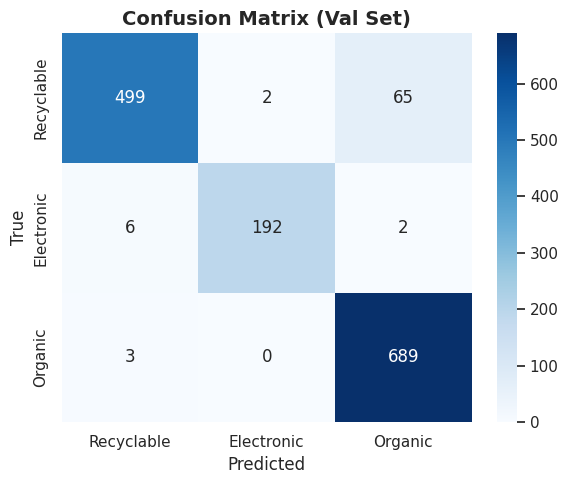

In [ ]:
# Confusion Matrix
cm = confusion_matrix(df_gt['predicted'], sub['predicted'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix (Val Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()


In [ ]:
compare = sub.copy()
compare['actual'] = df_gt['predicted']

compare.head(20)

,id,predicted,actual
0,1,2,2
1,2,2,2
2,3,2,2
3,4,1,1
4,5,0,0
5,6,2,0
6,7,2,2
7,8,0,0
8,9,1,1
9,10,2,2
